# Feed Forward Neural Network


**Experiments run:**

| # | Experiment            | Spatial unit   | Temporal bin | Comparison group |
|---|-----------------------|----------------|--------------|-------------------|
| 1 | Community Area (1h)   | Community Area | 1 hour       | Spatial & Temporal (baseline) |
| 2 | Census Tract (1h)     | Census Tract   | 1 hour       | Spatial |
| 3 | Community Area (4h)   | Community Area | 4 hours      | Temporal |
| 4 | Community Area (1d)   | Community Area | 1 day        | Temporal |

For every experiment we train the same **feed-forward architecture**, using
the **same train/validation/test split methodology** (three pre-split
parquet files per dataset) and the **same preprocessing** steps. Two things
are tuned automatically instead of being fixed by hand:

- The **number of hidden layers** is chosen once via a depth search on the
  baseline dataset (Section 6) and then fixed for every experiment.
- The **remaining hyperparameters** (embedding size, layer width, learning
  rate, weight decay, dropout, batch size) are tuned **separately for each
  experiment** (Section 7), so each spatial/temporal resolution gets its own
  best configuration rather than reusing one shared set.

The spatial identifier (`community_area` or `census_tract`, whichever the
dataset uses) is treated as a categorical feature and given a learned
**embedding**, rather than being fed in as a raw number.

For each experiment we report:
- **R² (Coefficient of Determination)**
- **MAE (Mean Absolute Error)**
- **rMAE (relative MAE)** -- MAE divided by the MAE of a naive baseline that
  always predicts the training set's mean trip count. Values below 1 mean
  the model beats that trivial baseline; unlike MAPE it doesn't need to
  exclude zero-count rows, which matters a lot here since several datasets
  are mostly zeros.
- **MAPE (Mean Absolute Percentage Error)**


If you are using quick/sample run, please set belows attribute accordingly:

In [22]:
QUICK_RUN = True

## 1. Setup

In [23]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")  # silence the benign "non-writable array" cast warning


In [24]:
# Reproducibility: fix every relevant random seed so the notebook gives the
# same results every time it's re-run from top to bottom.
SEED = 42

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    # No GPU available -- at least use every CPU core for PyTorch's internal
    # matmul/conv kernels instead of defaulting to a single thread.
    torch.set_num_threads(os.cpu_count())
    print(f"CPU threads set to: {torch.get_num_threads()} (of {os.cpu_count()} available)")


Using device: cpu
CPU threads set to: 24 (of 24 available)


## 2. Model architecture

In [25]:
class Model(nn.Module):

    def __init__(self, num_categories, embedding_dim, num_continuous, hidden_sizes, dropout, out_features=1):
        super().__init__()
        self.embedding = nn.Embedding(num_categories, embedding_dim)
        input_dim = embedding_dim + num_continuous

        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        self.hidden = nn.Sequential(*layers)
        self.out = nn.Linear(prev_dim, out_features)

    def forward(self, x_cat, x_cont):
        embedded = self.embedding(x_cat)          # [batch, embedding_dim]
        x = torch.cat([embedded, x_cont], dim=1)  # combine spatial embedding with the other features
        x = self.hidden(x)
        x = self.out(x)
        return x


In [26]:
def make_hidden_sizes(num_layers, start_width=32, min_width=4):
    """Build a list of hidden-layer widths for a given depth, halving the
    width at each additional layer (e.g. num_layers=3, start_width=32 ->
    [32, 16, 8]). Used by both the hidden-layer depth search (Section 6) and
    the per-experiment hyperparameter search (Section 7)."""
    return [max(min_width, start_width // (2 ** i)) for i in range(num_layers)]


## 3. Dataset registry

In [27]:
BASE_DIR = "../data/03/"

def paths(prefix):
    """Build the {train, val, test} path dict for a given file prefix."""
    return {
        "train": os.path.join(BASE_DIR, f"{prefix}_train.parquet"),
        "val":   os.path.join(BASE_DIR, f"{prefix}_val.parquet"),
        "test":  os.path.join(BASE_DIR, f"{prefix}_test.parquet"),
    }

# group: "spatial"  -> part of the Community Area vs Census Tract comparison
#        "temporal" -> part of the 1h vs 4h vs 1d comparison
#        "both"     -> the shared 1h / Community Area baseline
DATASETS = {
    "Community Area (1h)": {"paths": paths("03_community_area_1h"), "group": "both",
                             "spatial_unit": "Community Area", "temporal_bin": "1 hour"},
    "Census Tract (1h)":    {"paths": paths("03_census_tract_1h"),  "group": "spatial",
                             "spatial_unit": "Census Tract",   "temporal_bin": "1 hour"},
    "Community Area (4h)":  {"paths": paths("03_community_area_4h"), "group": "temporal",
                              "spatial_unit": "Community Area", "temporal_bin": "4 hours"},
    "Community Area (1d)":  {"paths": paths("03_community_area_1d"), "group": "temporal",
                              "spatial_unit": "Community Area", "temporal_bin": "1 day"},
}

list(DATASETS.keys())


['Community Area (1h)',
 'Census Tract (1h)',
 'Community Area (4h)',
 'Community Area (1d)']

## 4. Data loading & preprocessing

The same preprocessing pipeline is applied **identically** to every dataset:

1. Read the pre-split train / validation / test parquet files.
2. Separate the target column (`trip_count`) from the features.
3. Pull out the spatial identifier column (`community_area` or
   `census_tract`, whichever is present) as a **categorical** feature and
   label-encode it into a contiguous `0..N-1` index for `nn.Embedding`.
4. **Standardize the remaining (continuous) features** (zero mean, unit
   variance), fit on the training split only and applied unchanged to
   validation/test. The spatial ID is *not* standardized -- it's an index,
   not a magnitude.
5. Convert everything to PyTorch tensors (`long` for the spatial ID, `float32`
   for everything else).


In [28]:
SPATIAL_ID_COLUMNS = ("community_area", "census_tract")

def load_and_prepare(path_dict, target_col="trip_count", verbose=True):
    """Load the train/val/test parquet files for one experiment, split off the
    spatial ID column for embedding, standardize the remaining features (fit
    on train only), and return ready-to-train tensors plus dataset metadata.

    Tensors are moved to `device` (GPU if available) right here, once, so
    every downstream training loop already has GPU-resident data with no
    per-batch transfer cost."""

    train_db = pd.read_parquet(path_dict["train"])
    val_db   = pd.read_parquet(path_dict["val"])
    test_db  = pd.read_parquet(path_dict["test"])
    if QUICK_RUN:
        train_db = train_db.head(500)
        val_db   = val_db.head(500)
        test_db  = test_db.head(500)
        print("[QUICK_RUN] train/val/test datasets trimmed to 500 rows.")

    X_train_df = train_db.drop(columns=[target_col])
    Y_train_df = train_db[target_col]

    X_val_df = val_db.drop(columns=[target_col])
    Y_val_df = val_db[target_col]

    X_test_df = test_db.drop(columns=[target_col])
    Y_test_df = test_db[target_col]

    if verbose:
        # Quick sanity check: flag any feature column with an unusually large
        # magnitude BEFORE scaling, and report the target's raw range.
        col_max_abs = X_train_df.abs().max().sort_values(ascending=False)
        print(f"  Target range: [{Y_train_df.min():.2f}, {Y_train_df.max():.2f}]")
        print(f"  Largest-magnitude feature: '{col_max_abs.index[0]}' (max abs value = {col_max_abs.iloc[0]:.2f})")

    # --- Spatial ID embedding ---
    # Whichever spatial identifier this dataset uses is categorical, not
    # continuous, so it's pulled out and label-encoded into a contiguous
    # 0..N-1 index for nn.Embedding instead of being standardized like the
    # other features.
    cat_col = next((c for c in SPATIAL_ID_COLUMNS if c in X_train_df.columns), None)
    if cat_col is None:
        raise ValueError(f"None of {SPATIAL_ID_COLUMNS} found in columns: {list(X_train_df.columns)}")

    cat_encoder = LabelEncoder().fit(
        pd.concat([X_train_df[cat_col], X_val_df[cat_col], X_test_df[cat_col]]).unique()
    )
    num_categories = len(cat_encoder.classes_)
    if verbose:
        print(f"  Spatial ID column: '{cat_col}' ({num_categories} distinct values) -> embedding")

    X_train_cat = cat_encoder.transform(X_train_df[cat_col].values)
    X_val_cat   = cat_encoder.transform(X_val_df[cat_col].values)
    X_test_cat  = cat_encoder.transform(X_test_df[cat_col].values)

    X_train_cont_df = X_train_df.drop(columns=[cat_col])
    X_val_cont_df   = X_val_df.drop(columns=[cat_col])
    X_test_cont_df  = X_test_df.drop(columns=[cat_col])

    # Standardize the remaining (continuous) features: fit the scaler on the
    # training split only, then apply the SAME transform to validation/test.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_cont_df.values)
    X_val_scaled   = scaler.transform(X_val_cont_df.values)
    X_test_scaled  = scaler.transform(X_test_cont_df.values)

    data = {
        "X_train_cat": torch.tensor(X_train_cat, dtype=torch.long).to(device),
        "X_val_cat":   torch.tensor(X_val_cat, dtype=torch.long).to(device),
        "X_test_cat":  torch.tensor(X_test_cat, dtype=torch.long).to(device),

        "X_train_cont": torch.tensor(X_train_scaled, dtype=torch.float32).to(device),
        "X_val_cont":   torch.tensor(X_val_scaled, dtype=torch.float32).to(device),
        "X_test_cont":  torch.tensor(X_test_scaled, dtype=torch.float32).to(device),

        "Y_train": torch.tensor(Y_train_df.values, dtype=torch.float32).to(device),
        "Y_val":   torch.tensor(Y_val_df.values, dtype=torch.float32).to(device),
        "Y_test":  torch.tensor(Y_test_df.values, dtype=torch.float32).to(device),

        "num_continuous": X_train_scaled.shape[1],
        "num_categories": num_categories,
        "cat_col": cat_col,
        "n_train": X_train_scaled.shape[0], "n_val": X_val_scaled.shape[0], "n_test": X_test_scaled.shape[0],
        "scaler": scaler,
        "cat_encoder": cat_encoder,
    }
    return data


## 5. Evaluation metrics

All metrics are computed on the (unscaled) `trip_count` target:

- **R²**: standard coefficient of determination.
- **MAE**: mean absolute error, in raw trip-count units. Directly comparable
  to the training loss below, since the model is trained with an L1 (MAE) loss.
- **rMAE**: relative MAE -- the model's MAE divided by the MAE of a naive
  baseline that always predicts the training set's mean trip count. An rMAE
  below 1 means the model beats that trivial baseline; above 1 means it's
  worse than just guessing the mean. Unlike MAPE, rMAE doesn't need to
  exclude rows where the true value is 0, which matters here since some
  datasets (e.g. Census Tract, 1h) are mostly zero-count rows.
- **MAPE**: mean absolute percentage error. Rows where the true value is 0 are
  excluded (percentage error is undefined when dividing by zero); the number
  of excluded rows is reported alongside the metric for transparency.


In [29]:
def compute_metrics(y_true, y_pred, naive_pred=None):
    """Return R^2, MAE, MAPE (%), and (if `naive_pred` is given) rMAE for a
    set of predictions.

    `naive_pred` should be a same-shaped tensor/array of naive baseline
    predictions (e.g. the training set's mean trip count, broadcast to every
    row) -- rMAE is the model's MAE divided by that baseline's MAE.
    """
    y_true = y_true.detach().cpu().numpy().flatten()
    y_pred = y_pred.detach().cpu().numpy().flatten()

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    nonzero_mask = y_true != 0
    n_excluded = int((~nonzero_mask).sum())
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100

    metrics = {"r2": r2, "mae": mae, "mape": mape, "mape_excluded_rows": n_excluded}

    if naive_pred is not None:
        if torch.is_tensor(naive_pred):
            naive_pred = naive_pred.detach().cpu().numpy().flatten()
        else:
            naive_pred = np.asarray(naive_pred).flatten()
        naive_mae = mean_absolute_error(y_true, naive_pred)
        metrics["rmae"] = mae / naive_mae if naive_mae > 0 else float("nan")

    return metrics


## 6. Hidden-layer depth search (baseline only)

Before tuning the rest of the hyperparameters, we first decide **how many
hidden layers** the network should have. This is tested once on the baseline
dataset (Community Area, 1-hour bins) by comparing candidate depths
`{1, 2, 3, 4}`, each with a halving-width pattern (e.g. depth 3 ->
`[32, 16, 8]`) and otherwise-default hyperparameters. The depth with the
lowest validation MAE is fixed as `BEST_NUM_HIDDEN_LAYERS` and reused for
every hyperparameter search and every experiment below.

Each candidate is trained with **early stopping** instead of a fixed epoch
count: training halts once its training loss stops improving by a meaningful
amount.


In [30]:
def train_and_evaluate(params, X_tr_cat, X_tr_cont, Y_tr, X_va_cat, X_va_cont, Y_va,
                        num_categories, max_epochs, patience, min_delta):
    """Train a fresh candidate model and return its validation MAE (L1 loss).

    Uses early stopping: training halts once the training loss stops
    improving by at least `min_delta` for `patience` epochs in a row, or once
    `max_epochs` is reached -- whichever comes first.
    """
    set_seed(0)  # same starting point for every candidate -> a fair comparison

    candidate = Model(
        num_categories=num_categories,
        embedding_dim=params["embedding_dim"],
        num_continuous=X_tr_cont.shape[1],
        hidden_sizes=params["hidden_sizes"],
        dropout=params["dropout"],
    ).to(device)  # X_tr_cat/X_tr_cont etc. are already on `device` (see load_and_prepare)
    candidate_optimizer = torch.optim.Adam(
        candidate.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    candidate_loss_fn = nn.L1Loss()

    search_loader = DataLoader(
        TensorDataset(X_tr_cat, X_tr_cont, Y_tr), batch_size=params["batch_size"], shuffle=True
    )

    best_epoch_loss = float("inf")
    epochs_no_improve = 0

    candidate.train()
    for _ in range(max_epochs):
        epoch_loss = 0.0
        for X_cat_batch, X_cont_batch, Y_batch in search_loader:
            Y_pred = candidate(X_cat_batch, X_cont_batch)
            error = candidate_loss_fn(Y_pred.squeeze(), Y_batch)

            candidate_optimizer.zero_grad()
            error.backward()
            candidate_optimizer.step()

            epoch_loss += error.item()

        epoch_loss /= len(search_loader)

        if epoch_loss < best_epoch_loss - min_delta:
            best_epoch_loss = epoch_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break  # training loss has plateaued for this candidate -> stop early

    candidate.eval()
    with torch.no_grad():
        Y_val_pred = candidate(X_va_cat, X_va_cont)
        val_loss = candidate_loss_fn(Y_val_pred.squeeze(), Y_va).item()

    return val_loss


In [31]:
# Load the baseline dataset used for the depth search.
baseline_data = load_and_prepare(DATASETS["Community Area (1h)"]["paths"])
print(f"Baseline (Community Area, 1h) -> "
      f"train: {baseline_data['n_train']} | val: {baseline_data['n_val']} | test: {baseline_data['n_test']} | "
      f"continuous features: {baseline_data['num_continuous']} | "
      f"'{baseline_data['cat_col']}' categories: {baseline_data['num_categories']}")


[QUICK_RUN] train/val/test datasets trimmed to 500 rows.
  Target range: [0.00, 93.00]
  Largest-magnitude feature: 'community_area' (max abs value = 77.00)
  Spatial ID column: 'community_area' (77 distinct values) -> embedding
Baseline (Community Area, 1h) -> train: 500 | val: 500 | test: 500 | continuous features: 32 | 'community_area' categories: 77


In [32]:
# Search on a random subsample of the training set for speed; the final
# models are still trained on the FULL training set for each experiment.
SEARCH_SAMPLE_SIZE = 50000   # was 70000 -- fewer rows per search trial

# Early-stopping settings used during ALL grid/depth searches below (kept
# separate from the final-training settings in Section 8, which are looser
# since they run on full datasets rather than a subsample).
MAX_EPOCHS_PER_COMBO = 20   # was 30 -- upper bound; early stopping should trigger well before this
SEARCH_PATIENCE = 3         # was 5 -- epochs to wait for improvement before stopping a candidate
SEARCH_MIN_DELTA = 1e-3     # minimum drop in training loss to count as "improvement"

DEPTH_CANDIDATES = [1, 2, 3, 4]  # number of hidden layers to try

set_seed()
sample_idx = torch.randperm(baseline_data["X_train_cont"].shape[0])[:SEARCH_SAMPLE_SIZE]
X_search_cat  = baseline_data["X_train_cat"][sample_idx]
X_search_cont = baseline_data["X_train_cont"][sample_idx]
Y_search      = baseline_data["Y_train"][sample_idx]

depth_results = []
start = time.time()
for depth in DEPTH_CANDIDATES:
    hidden_sizes = make_hidden_sizes(depth)
    depth_params = {
        "embedding_dim": 8, "hidden_sizes": hidden_sizes,
        "lr": 0.001, "weight_decay": 0, "dropout": 0.0, "batch_size": 128,
    }
    val_loss = train_and_evaluate(
        depth_params, X_search_cat, X_search_cont, Y_search,
        baseline_data["X_val_cat"], baseline_data["X_val_cont"], baseline_data["Y_val"],
        num_categories=baseline_data["num_categories"],
        max_epochs=MAX_EPOCHS_PER_COMBO, patience=SEARCH_PATIENCE, min_delta=SEARCH_MIN_DELTA,
    )
    depth_results.append({"num_hidden_layers": depth, "hidden_sizes": hidden_sizes, "val_loss": val_loss})
    print(f"[depth={depth}] hidden_sizes={hidden_sizes} val_loss={val_loss:.4f}  (elapsed: {time.time() - start:.0f}s)")

depth_df = pd.DataFrame(depth_results).sort_values("val_loss").reset_index(drop=True)
BEST_NUM_HIDDEN_LAYERS = int(depth_df.iloc[0]["num_hidden_layers"])
best_depth_hidden_sizes = depth_df.iloc[0]["hidden_sizes"]
best_depth_val_loss = depth_df.iloc[0]["val_loss"]

print(f"\nBest number of hidden layers: {BEST_NUM_HIDDEN_LAYERS} "
      f"(hidden_sizes={best_depth_hidden_sizes}, val MAE={best_depth_val_loss:.4f})")
print("This depth is now fixed and reused for the per-experiment hyperparameter search below.")
depth_df


[depth=1] hidden_sizes=[32] val_loss=3.2411  (elapsed: 0s)
[depth=2] hidden_sizes=[32, 16] val_loss=3.4074  (elapsed: 0s)
[depth=3] hidden_sizes=[32, 16, 8] val_loss=3.2648  (elapsed: 0s)
[depth=4] hidden_sizes=[32, 16, 8, 4] val_loss=3.3238  (elapsed: 1s)

Best number of hidden layers: 1 (hidden_sizes=[32], val MAE=3.2411)
This depth is now fixed and reused for the per-experiment hyperparameter search below.


,num_hidden_layers,hidden_sizes,val_loss
0,1,[32],3.241146
1,3,"[32, 16, 8]",3.264765
2,4,"[32, 16, 8, 4]",3.323761
3,2,"[32, 16]",3.407376


## 7. Hyperparameter tuning (per experiment)

Unlike depth (fixed once above), the remaining hyperparameters -- embedding
size, layer width, learning rate, weight decay, dropout, batch size -- are
now tuned **separately for each experiment**, using that experiment's own
training subsample and validation set. This lets each spatial/temporal
resolution pick the hyperparameters that suit its own data, at the cost of
no longer sharing one fixed configuration across experiments.

Each candidate still trains with **early stopping**, exactly as in the depth
search above.


In [33]:
def build_param_grid(num_hidden_layers):
    """Hyperparameter grid to search, for a fixed number of hidden layers.
    `start_width` is expanded into an actual `hidden_sizes` list (halving
    pattern, via make_hidden_sizes) for each candidate before training.

    Trimmed down from the original grid (144 combos/experiment) to keep the
    search tractable: start_width now spans just its low/high ends instead
    of low/mid/high, weight_decay drops its middle value, and batch_size is
    fixed at 128 (larger batches -> fewer optimizer steps per epoch -> faster
    wall-clock time on CPU, with negligible effect on final quality here).
    This is 2*2*2*2*2*1 = 32 combos/experiment, a ~4.5x cut."""
    raw_grid = list(ParameterGrid({
        "embedding_dim": [4, 8],
        "start_width":   [16, 64],       # was [16, 32, 64]
        "lr":            [0.001, 0.003],
        "weight_decay":  [0, 1e-4],      # was [0, 1e-5, 1e-4]
        "dropout":       [0.0, 0.1],
        "batch_size":    [128],          # was [64, 128]
    }))
    if QUICK_RUN:
        raw_grid = raw_grid[:1]
    for combo in raw_grid:
        combo["hidden_sizes"] = make_hidden_sizes(num_hidden_layers, combo["start_width"])
    return raw_grid


if QUICK_RUN:
    MAX_EPOCHS_PER_COMBO = 2
def tune_hyperparameters(data, num_hidden_layers, sample_size=SEARCH_SAMPLE_SIZE,
                          max_epochs=MAX_EPOCHS_PER_COMBO, patience=SEARCH_PATIENCE, min_delta=SEARCH_MIN_DELTA):
    """Grid-search the hyperparameters above for one experiment's dataset,
    using a random training subsample for speed. Returns (best_params dict,
    full results DataFrame sorted by validation MAE)."""
    set_seed()
    n = data["X_train_cont"].shape[0]
    sample_idx = torch.randperm(n)[:min(sample_size, n)]
    X_s_cat  = data["X_train_cat"][sample_idx]
    X_s_cont = data["X_train_cont"][sample_idx]
    Y_s      = data["Y_train"][sample_idx]

    grid = build_param_grid(num_hidden_layers)
    rows = []
    for grid_params in grid:
        val_loss = train_and_evaluate(
            grid_params, X_s_cat, X_s_cont, Y_s,
            data["X_val_cat"], data["X_val_cont"], data["Y_val"],
            num_categories=data["num_categories"],
            max_epochs=max_epochs, patience=patience, min_delta=min_delta,
        )
        rows.append({**grid_params, "val_loss": val_loss})

    search_df = pd.DataFrame(rows).sort_values("val_loss").reset_index(drop=True)
    best_params = search_df.iloc[0].to_dict()
    return best_params, search_df


## 8. Final training routine

A single function trains a full model on a given training set using whatever
`params` dict it's handed (that experiment's own tuned hyperparameters from
Section 7), tracking the loss curve for later plotting. This exact function
is reused for every experiment, so training itself is identical across all
of them -- only the hyperparameters and the resulting model differ.

Instead of a fixed number of epochs, training uses **early stopping** on
that experiment's own validation set: it halts once validation loss stops
improving by a meaningful amount for several epochs in a row, and restores
the weights from the best-performing epoch (not just whatever epoch it
happened to stop on).


In [34]:
MAX_EPOCHS = 50           # was 100 -- generous upper bound; early stopping should trigger well before this
FINAL_PATIENCE = 5        # was 10 -- epochs to wait for a validation improvement before stopping
FINAL_MIN_DELTA = 1e-4    # minimum drop in validation loss to count as real improvement

def train_final_model(data, params, max_epochs=MAX_EPOCHS, patience=FINAL_PATIENCE, min_delta=FINAL_MIN_DELTA):
    """Train a model on the full training set of one experiment's dataset,
    with early stopping on that experiment's own validation set."""
    set_seed(0)  # same initial weights for every experiment -> fair comparison

    model = Model(
        num_categories=data["num_categories"],
        embedding_dim=int(params["embedding_dim"]),
        num_continuous=data["num_continuous"],
        hidden_sizes=params["hidden_sizes"],
        dropout=params["dropout"],
        out_features=1,
    ).to(device)  # data's tensors are already on `device` (see load_and_prepare)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    loss_fn = nn.L1Loss()

    train_loader = DataLoader(
        TensorDataset(data["X_train_cat"], data["X_train_cont"], data["Y_train"]),
        batch_size=int(params["batch_size"]),
        shuffle=True,
    )

    loss_history = []
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_cat_batch, X_cont_batch, Y_batch in train_loader:
            Y_pred = model(X_cat_batch, X_cont_batch).squeeze()
            error = loss_fn(Y_pred, Y_batch)

            optimizer.zero_grad()
            error.backward()
            optimizer.step()

            epoch_loss += error.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        model.eval()
        with torch.no_grad():
            Y_val_pred = model(data["X_val_cat"], data["X_val_cont"]).squeeze()
            val_loss = loss_fn(Y_val_pred, data["Y_val"]).item()

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}  # checkpoint best model
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break  # validation loss has stopped improving meaningfully

    if best_state is not None:
        model.load_state_dict(best_state)  # restore weights from the best epoch, not the last one

    return model, loss_history


## 9. Run every experiment

For each dataset in the registry: load & preprocess the data, tune that
experiment's own hyperparameters (Section 7, using the hidden-layer depth
fixed in Section 6), train the final model with early stopping, then
evaluate on the held-out test set.

In [35]:
experiment_results = []
loss_curves = {}
predictions = {}
tuned_hyperparams = {}

for name, cfg in DATASETS.items():
    print(f"\n=== {name} ===")

    data = baseline_data if name == "Community Area (1h)" else load_and_prepare(cfg["paths"])
    print(f"train: {data['n_train']} | val: {data['n_val']} | test: {data['n_test']} | "
          f"continuous features: {data['num_continuous']} | "
          f"'{data['cat_col']}' categories: {data['num_categories']}")

    # --- Tune this experiment's own hyperparameters ---
    t_tune = time.time()
    best_params, search_df = tune_hyperparameters(data, BEST_NUM_HIDDEN_LAYERS)
    tuned_hyperparams[name] = best_params
    print(
        f"Tuned in {time.time() - t_tune:.0f}s -> best hyperparameters: "
        f"embedding_dim={best_params['embedding_dim']}, hidden_sizes={best_params['hidden_sizes']}, "
        f"lr={best_params['lr']}, weight_decay={best_params['weight_decay']}, "
        f"dropout={best_params['dropout']}, batch_size={best_params['batch_size']} "
        f"(search val MAE={best_params['val_loss']:.4f})"
    )

    # --- Train the final model with those hyperparameters ---
    t0 = time.time()
    model, loss_history = train_final_model(data, best_params)
    print(f"Trained in {time.time() - t0:.0f}s -> final training loss: {loss_history[-1]:.4f}")

    model.eval()
    with torch.no_grad():
        y_pred_test = model(data["X_test_cat"], data["X_test_cont"]).squeeze()

    # Naive baseline for rMAE: always predict the training set's mean trip count.
    naive_pred_test = torch.full_like(data["Y_test"], data["Y_train"].mean())
    metrics = compute_metrics(data["Y_test"], y_pred_test, naive_pred=naive_pred_test)
    print(
        f"Test R^2: {metrics['r2']:.4f} | Test MAE: {metrics['mae']:.4f} | Test rMAE: {metrics['rmae']:.4f} | "
        f"Test MAPE: {metrics['mape']:.2f}% (excluded {metrics['mape_excluded_rows']} zero-count rows)"
    )

    # Prediction-collapse check: if the model just learned to predict close
    # to a constant (e.g. the target's mean), pred_std will be tiny relative
    # to actual_std even though R^2/MAE/MAPE alone might not make that obvious.
    y_true_np = data["Y_test"].detach().cpu().numpy().flatten()
    y_pred_np = y_pred_test.detach().cpu().numpy().flatten()
    pred_std_ratio = y_pred_np.std() / y_true_np.std() if y_true_np.std() > 0 else float("nan")
    print(f"Actual: mean={y_true_np.mean():.2f}, std={y_true_np.std():.2f} | "
          f"Predicted: mean={y_pred_np.mean():.2f}, std={y_pred_np.std():.2f} | "
          f"pred_std/actual_std={pred_std_ratio:.3f}")
    if pred_std_ratio < 0.2:
        print("  Warning: predicted values vary far less than actual values -- "
              "the model may have collapsed toward predicting a near-constant value.")

    experiment_results.append({
        "experiment": name,
        "group": cfg["group"],
        "spatial_unit": cfg["spatial_unit"],
        "temporal_bin": cfg["temporal_bin"],
        "n_train": data["n_train"],
        "n_test": data["n_test"],
        "num_continuous": data["num_continuous"],
        "num_categories": data["num_categories"],
        "r2": metrics["r2"],
        "mae": metrics["mae"],
        "rmae": metrics["rmae"],
        "mape": metrics["mape"],
        "embedding_dim": best_params["embedding_dim"],
        "hidden_sizes": str(best_params["hidden_sizes"]),
        "lr": best_params["lr"],
        "weight_decay": best_params["weight_decay"],
        "dropout": best_params["dropout"],
        "batch_size": best_params["batch_size"],
    })
    loss_curves[name] = loss_history
    predictions[name] = (y_true_np, y_pred_np)



=== Community Area (1h) ===
train: 500 | val: 500 | test: 500 | continuous features: 32 | 'community_area' categories: 77
Tuned in 0s -> best hyperparameters: embedding_dim=4, hidden_sizes=[16], lr=0.001, weight_decay=0, dropout=0.0, batch_size=128 (search val MAE=4.0454)
Trained in 0s -> final training loss: 1.5415
Test R^2: -0.0244 | Test MAE: 5.1803 | Test rMAE: 1.6247 | Test MAPE: 230.81% (excluded 338 zero-count rows)
Actual: mean=2.36, std=14.32 | Predicted: mean=4.23, std=1.19 | pred_std/actual_std=0.083

=== Census Tract (1h) ===
[QUICK_RUN] train/val/test datasets trimmed to 500 rows.
  Target range: [0.00, 13.00]
  Largest-magnitude feature: 'census_tract' (max abs value = 17031980100.00)
  Spatial ID column: 'census_tract' (115 distinct values) -> embedding
train: 500 | val: 500 | test: 500 | continuous features: 32 | 'census_tract' categories: 115
Tuned in 0s -> best hyperparameters: embedding_dim=4, hidden_sizes=[16], lr=0.001, weight_decay=0, dropout=0.0, batch_size=128 

## 10. Results table

In [36]:
results_df = pd.DataFrame(experiment_results)
results_df = results_df[["experiment", "group", "spatial_unit", "temporal_bin",
                          "n_train", "n_test", "num_continuous", "num_categories",
                          "r2", "mae", "rmae", "mape",
                          "embedding_dim", "hidden_sizes", "lr", "weight_decay", "dropout", "batch_size"]]
results_df.style.format({
    "r2": "{:.4f}", "mae": "{:.3f}", "rmae": "{:.3f}", "mape": "{:.2f}%",
})


,experiment,group,spatial_unit,temporal_bin,n_train,n_test,num_continuous,num_categories,r2,mae,rmae,mape,embedding_dim,hidden_sizes,lr,weight_decay,dropout,batch_size
0,Community Area (1h),both,Community Area,1 hour,500,500,32,77,-0.0244,5.180,1.625,230.81%,4,[16],0.001000,0,0.000000,128
1,Census Tract (1h),spatial,Census Tract,1 hour,500,500,32,115,-0.2250,2.867,5.856,62.57%,4,[16],0.001000,0,0.000000,128
2,Community Area (4h),temporal,Community Area,4 hours,500,485,32,77,-0.0482,36.818,0.687,79.56%,4,[16],0.001000,0,0.000000,128
3,Community Area (1d),temporal,Community Area,1 day,379,80,32,77,-0.0952,272.407,0.769,90.90%,4,[16],0.001000,0,0.000000,128


## 11. Spatial resolution comparison

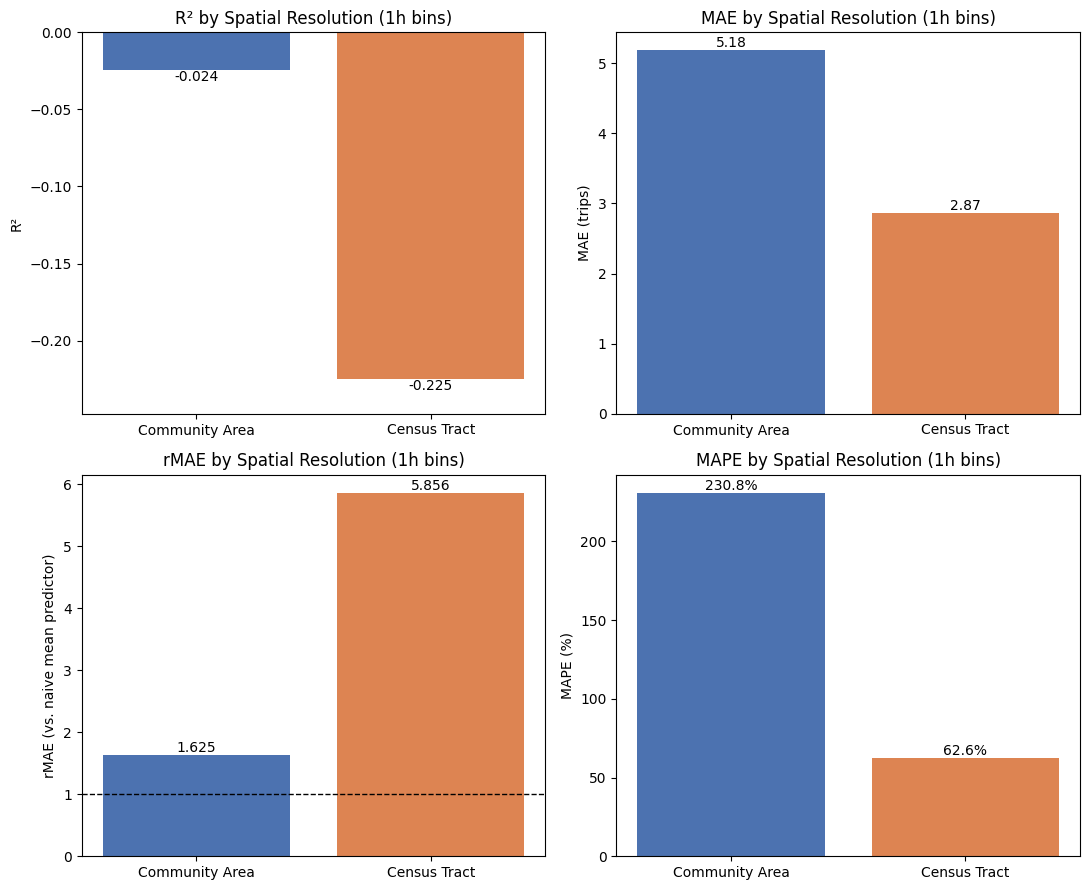

In [37]:
#| label: fig-nn-spatial-comparison
#| fig-cap: "Neural network performance by spatial resolution (1h bins)."
spatial_df = results_df[results_df["group"].isin(["spatial", "both"])].copy()
spatial_df = spatial_df[spatial_df["temporal_bin"] == "1 hour"]
spatial_df = spatial_df.set_index("spatial_unit").loc[["Community Area", "Census Tract"]]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].bar(spatial_df.index, spatial_df["r2"], color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("R\u00b2 by Spatial Resolution (1h bins)")
axes[0, 0].set_ylabel("R\u00b2")
axes[0, 0].set_ylim(bottom=min(0, spatial_df["r2"].min() * 1.1))
for i, v in enumerate(spatial_df["r2"]):
    axes[0, 0].text(i, v, f"{v:.3f}", ha="center", va="bottom" if v >= 0 else "top")

axes[0, 1].bar(spatial_df.index, spatial_df["mae"], color=["#4C72B0", "#DD8452"])
axes[0, 1].set_title("MAE by Spatial Resolution (1h bins)")
axes[0, 1].set_ylabel("MAE (trips)")
for i, v in enumerate(spatial_df["mae"]):
    axes[0, 1].text(i, v, f"{v:.2f}", ha="center", va="bottom")

axes[1, 0].bar(spatial_df.index, spatial_df["rmae"], color=["#4C72B0", "#DD8452"])
axes[1, 0].set_title("rMAE by Spatial Resolution (1h bins)")
axes[1, 0].set_ylabel("rMAE (vs. naive mean predictor)")
axes[1, 0].axhline(1.0, color="black", linestyle="--", linewidth=1)  # rMAE = 1 -> ties the naive baseline
for i, v in enumerate(spatial_df["rmae"]):
    axes[1, 0].text(i, v, f"{v:.3f}", ha="center", va="bottom")

axes[1, 1].bar(spatial_df.index, spatial_df["mape"], color=["#4C72B0", "#DD8452"])
axes[1, 1].set_title("MAPE by Spatial Resolution (1h bins)")
axes[1, 1].set_ylabel("MAPE (%)")
for i, v in enumerate(spatial_df["mape"]):
    axes[1, 1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("../data/08/spatial_resolution_comparison.png", dpi=200)
plt.show()


## 12. Temporal resolution comparison

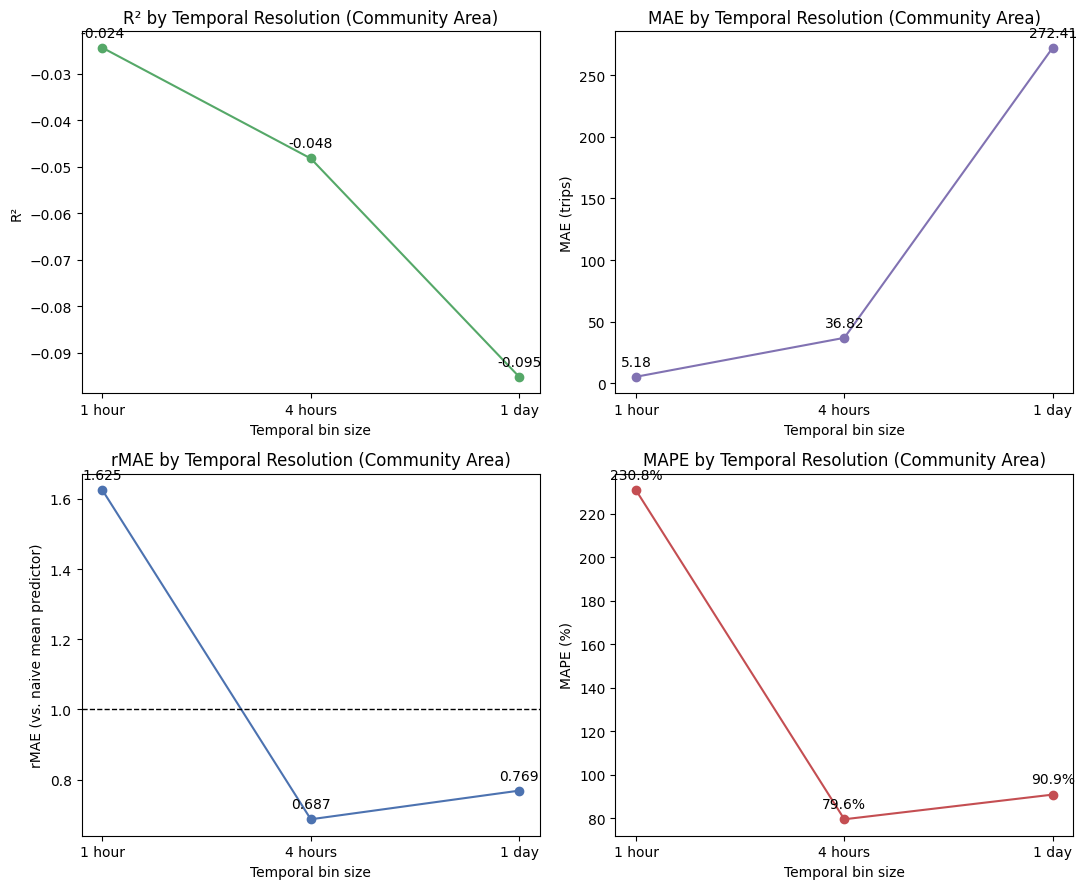

In [38]:
#| label: fig-nn-temporal-comparison
#| fig-cap: "Neural network performance by temporal resolution (community areas)."
temporal_order = ["1 hour", "4 hours", "1 day"]
temporal_df = results_df[results_df["group"].isin(["temporal", "both"])].copy()
temporal_df = temporal_df.set_index("temporal_bin").loc[temporal_order]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].plot(temporal_df.index, temporal_df["r2"], marker="o", color="#55A868")
axes[0, 0].set_title("R\u00b2 by Temporal Resolution (Community Area)")
axes[0, 0].set_ylabel("R\u00b2")
axes[0, 0].set_xlabel("Temporal bin size")
for x, v in zip(temporal_df.index, temporal_df["r2"]):
    axes[0, 0].annotate(f"{v:.3f}", (x, v), textcoords="offset points", xytext=(0, 8), ha="center")

axes[0, 1].plot(temporal_df.index, temporal_df["mae"], marker="o", color="#8172B2")
axes[0, 1].set_title("MAE by Temporal Resolution (Community Area)")
axes[0, 1].set_ylabel("MAE (trips)")
axes[0, 1].set_xlabel("Temporal bin size")
for x, v in zip(temporal_df.index, temporal_df["mae"]):
    axes[0, 1].annotate(f"{v:.2f}", (x, v), textcoords="offset points", xytext=(0, 8), ha="center")

axes[1, 0].plot(temporal_df.index, temporal_df["rmae"], marker="o", color="#4C72B0")
axes[1, 0].set_title("rMAE by Temporal Resolution (Community Area)")
axes[1, 0].set_ylabel("rMAE (vs. naive mean predictor)")
axes[1, 0].set_xlabel("Temporal bin size")
axes[1, 0].axhline(1.0, color="black", linestyle="--", linewidth=1)
for x, v in zip(temporal_df.index, temporal_df["rmae"]):
    axes[1, 0].annotate(f"{v:.3f}", (x, v), textcoords="offset points", xytext=(0, 8), ha="center")

axes[1, 1].plot(temporal_df.index, temporal_df["mape"], marker="o", color="#C44E52")
axes[1, 1].set_title("MAPE by Temporal Resolution (Community Area)")
axes[1, 1].set_ylabel("MAPE (%)")
axes[1, 1].set_xlabel("Temporal bin size")
for x, v in zip(temporal_df.index, temporal_df["mape"]):
    axes[1, 1].annotate(f"{v:.1f}%", (x, v), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("../data/08/temporal_resolution_comparison.png", dpi=200)
plt.show()


## 13. Training loss curves

Each experiment now stops at its own point (early stopping), so curves may
have different lengths -- that's expected, not a bug. The y-axis is
log-scaled: absolute loss values differ a lot across experiments (different
temporal bins produce very different trip-count magnitudes), and the log
scale keeps all four curves readable on one plot.


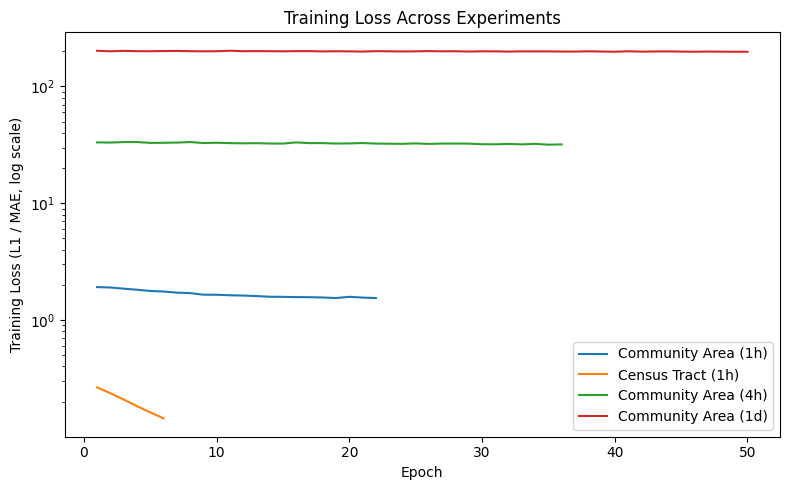

In [39]:
#| label: fig-nn-loss-curves
#| fig-cap: "Training loss curves across all four experiments."
plt.figure(figsize=(8, 5))
for name, history in loss_curves.items():
    plt.plot(range(1, len(history) + 1), history, label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (L1 / MAE, log scale)")
plt.title("Training Loss Across Experiments")
plt.legend()
plt.tight_layout()
plt.savefig("../data/08/training_loss_curves.png", dpi=200)
plt.show()


## 14. Predicted vs. actual (test set)

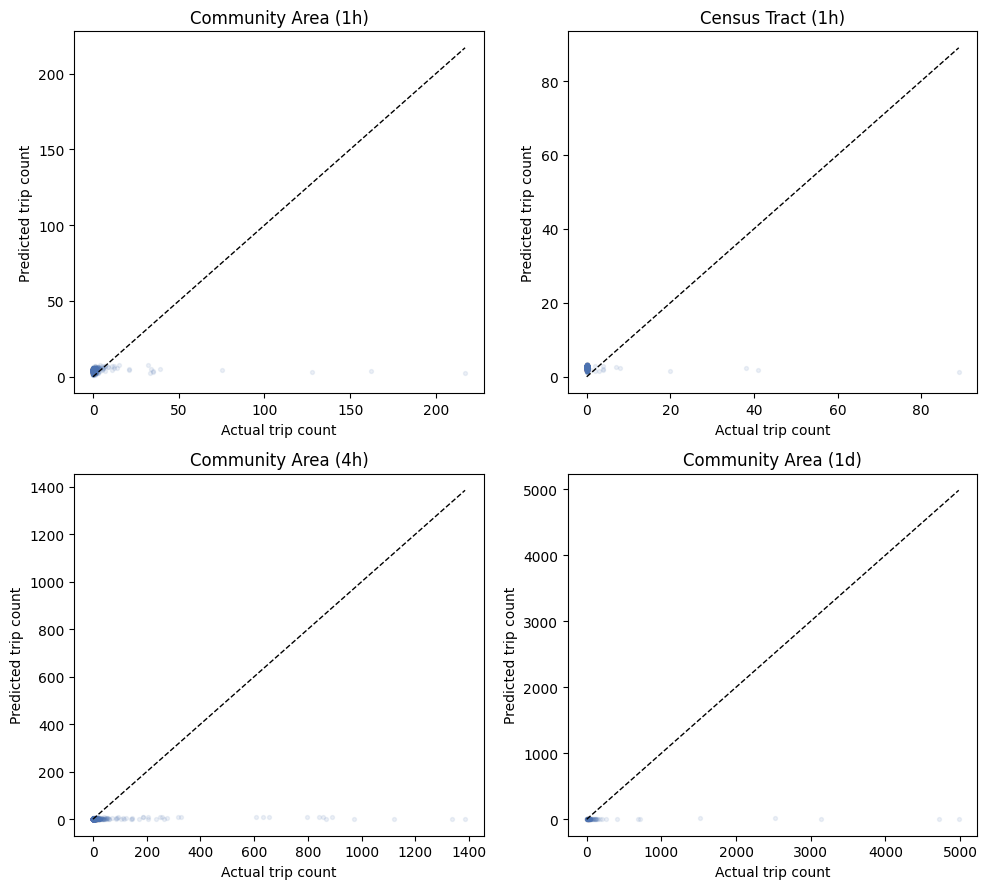

In [40]:
#| label: fig-nn-predicted-vs-actual
#| fig-cap: "Predicted versus actual trip counts on the test set."
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, (name, (y_true, y_pred)) in zip(axes.flat, predictions.items()):
    ax.scatter(y_true, y_pred, alpha=0.1, s=8, color="#4C72B0")
    lims = [0, max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual trip count")
    ax.set_ylabel("Predicted trip count")

plt.tight_layout()
plt.savefig("../data/08/predicted_vs_actual.png", dpi=200)
plt.show()


## 15. Checking number of correct predictions


In [41]:
#| label: tbl-nn-accuracy
#| tbl-cap: "Neural network prediction accuracy under absolute and relative tolerances."
def accuracy_report(y_true, y_pred, abs_tolerances=(0, 1, 2, 5), rel_tolerances=(0.10, 0.20)):
    """Return 'correct prediction' rates under several tolerance definitions.

    - abs_tolerances[0] == 0  -> exact match on the rounded prediction.
    - remaining abs_tolerances -> within +/- N trips of the actual count.
    - rel_tolerances           -> within +/- X% of the actual count
                                  (rows with actual == 0 are excluded, same
                                  convention as the MAPE computation above).
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred_rounded = np.round(y_pred)
    abs_err = np.abs(y_pred_rounded - y_true)

    report = {"n_test": len(y_true)}

    for tol in abs_tolerances:
        label = "exact_match" if tol == 0 else f"within_{tol}_trips"
        report[label] = float(np.mean(abs_err <= tol))

    nonzero_mask = y_true != 0
    rel_err = np.abs(y_pred[nonzero_mask] - y_true[nonzero_mask]) / y_true[nonzero_mask]
    for tol in rel_tolerances:
        label = f"within_{int(tol * 100)}pct"
        report[label] = float(np.mean(rel_err <= tol))

    return report


accuracy_rows = []
for name, (y_true, y_pred) in predictions.items():
    row = {"experiment": name}
    row.update(accuracy_report(y_true, y_pred))
    accuracy_rows.append(row)

accuracy_df = pd.DataFrame(accuracy_rows)

pct_cols = [c for c in accuracy_df.columns if c not in ("experiment", "n_test")]
accuracy_df.style.format({c: "{:.1%}" for c in pct_cols})


,experiment,n_test,exact_match,within_1_trips,within_2_trips,within_5_trips,within_10pct,within_20pct
0,Community Area (1h),500,2.0%,6.0%,17.8%,94.4%,5.6%,6.2%
1,Census Tract (1h),500,0.2%,2.4%,44.4%,99.0%,0.0%,7.7%
2,Community Area (4h),485,15.7%,37.1%,45.6%,62.3%,2.0%,5.7%
3,Community Area (1d),80,0.0%,2.5%,5.0%,12.5%,0.0%,0.0%


## 16. Save results

Write both results tables to disk so they can be dropped straight into the report.


In [43]:
results_df.to_csv(f"../data/08/resolution_comparison_results.csv", index=False)
accuracy_df.to_csv(f"../data/08/resolution_comparison_accuracy.csv", index=False)
print("Saved results_df to ../data/08/resolution_comparison_results.csv")
print("Saved accuracy_df to ../data/08/resolution_comparison_accuracy.csv")
results_df


Saved results_df to ../data/08/resolution_comparison_results.csv
Saved accuracy_df to ../data/08/resolution_comparison_accuracy.csv


,experiment,group,spatial_unit,temporal_bin,n_train,n_test,num_continuous,num_categories,r2,mae,rmae,mape,embedding_dim,hidden_sizes,lr,weight_decay,dropout,batch_size
0,Community Area (1h),both,Community Area,1 hour,500,500,32,77,-0.024396,5.180286,1.624696,230.805389,4,[16],0.001,0,0.0,128
1,Census Tract (1h),spatial,Census Tract,1 hour,500,500,32,115,-0.224998,2.867051,5.855810,62.567638,4,[16],0.001,0,0.0,128
2,Community Area (4h),temporal,Community Area,4 hours,500,485,32,77,-0.048226,36.818058,0.686885,79.559265,4,[16],0.001,0,0.0,128
3,Community Area (1d),temporal,Community Area,1 day,379,80,32,77,-0.095209,272.406891,0.768501,90.898735,4,[16],0.001,0,0.0,128
